In [199]:
import sys
sys.path.append("..")
%run "../moduli.py"

In [200]:
tipo = "sfasamento"
cartella_output = "profilazione_sfasamento"

In [201]:
pickle_fit = tipo + ".pkl"
json_fit = tipo + ".json"

# Usa variabili globali y_off
def modello(par, f): # Capi di R
    Omega, Q = par
    omega = 2 * np.pi * (f + x_off)
    #omega = f + x_off
    return np.arctan(
        -Q * ((Omega / omega) - (omega / Omega))
    ) + y_off

param_labels = ["\\Omega", "Q"]

xlabel = "\\Omega"
xunit = "rad/s"
ylabel = "Q"
yunit = "-"

# Lettura

Lettura del file Json

In [202]:
with open(json_fit) as f:
    nomi = json.load(f)

file_input = os.path.join(nomi["cartella"],nomi["file_input"])

os.makedirs(cartella_output, exist_ok=True)

dati = let.csv_to_dict(file_input)
x = Misura(dati["x"],dati["sx"])
y = Misura(dati["y"],dati["sy"])
del dati

grafico_output1 = os.path.join(
    cartella_output,
    "profilazione_3d.pdf"
)
grafico_output2 = os.path.join(
    cartella_output,
    "profilazione_2d.pdf"
)

Lettura del file Pickle

In [203]:
a = Misura(None, None)
b = Misura(None, None)
anal,offset = let.importa_pickle(pickle_fit)
[[a.val, b.val], [a.s, b.s]] = anal
[x_off, y_off] = offset
del anal,offset

# Creazione $\chi^2$

Funziona solamente per modelli a tre parametri.

In [204]:
# Usa variabili globali 
def fitchi2(i,j):
    AA,BB = a_range[i],b_range[j]
    # Chi Quadro
    residuals = (y.val -  modello([AA,BB], x.val))
    chi2 = np.sum((residuals/y.s)**2)
    CHI[i,j] = chi2

# Creazione dei range per i parametri da profilare
step = 100
larghezza = [2,2]  # Bilanciato: esplora range comparabili

a_range = np.linspace(a.val - larghezza[0]*a.s, a.val + larghezza[0]*a.s, step)
b_range = np.linspace(b.val - larghezza[1]*b.s, b.val + larghezza[1]*b.s, step)

# Creazione di una matrice per memorizzare i valori di chi quadro
import multiprocessing.pool

CHI = np.zeros((step,step))
item = [(i,j) for i in range(step) for j in range(step)]

# assign the global pool
pool = multiprocessing.pool.ThreadPool(100)
# issue top level tasks to pool and wait
pool.starmap(fitchi2, item, chunksize=10)
# close the pool
pool.close()

CHI = np.asarray(CHI)

index_a_min, index_b_min = np.unravel_index(np.argmin(CHI), CHI.shape)
index = [index_a_min, index_b_min]

Profilazione della matrice CHI.

In [205]:
def profilo(mappa, axes, func=np.min):
    axes = tuple(a-1 for a in axes)
    return func(mappa, axis=axes)

# proiezioni 2D
ab_map = CHI

# proiezioni 1D
a_prof = profilo(CHI, [2])
b_prof = profilo(CHI, [1])

# Grafici

In [206]:
x_range = a_range
y_range = b_range

xy_map = ab_map
x_prof = a_prof
y_prof = b_prof

index_x_min = index_a_min
index_y_min = index_b_min
chi_min = xy_map[index_x_min, index_y_min]
x_min = x_range[index_x_min]
y_min = y_range[index_y_min]

Range del grafico

In [207]:
zoom = 0.5  # Ridotto da 0.5 perché la scala ora è diversa

dx = np.max(x_range) - np.min(x_range)
dy = np.max(y_range) - np.min(y_range)
dchi = np.max(xy_map) - np.min(xy_map)

xlim = (np.min(x_range) - zoom * dx,
        np.max(x_range) + zoom * dx)
ylim = (np.min(y_range) - zoom * dy,
        np.max(y_range) + zoom * dy)
zlim = (np.min(xy_map) - zoom * dchi,
        np.max(xy_map) + zoom * dchi)

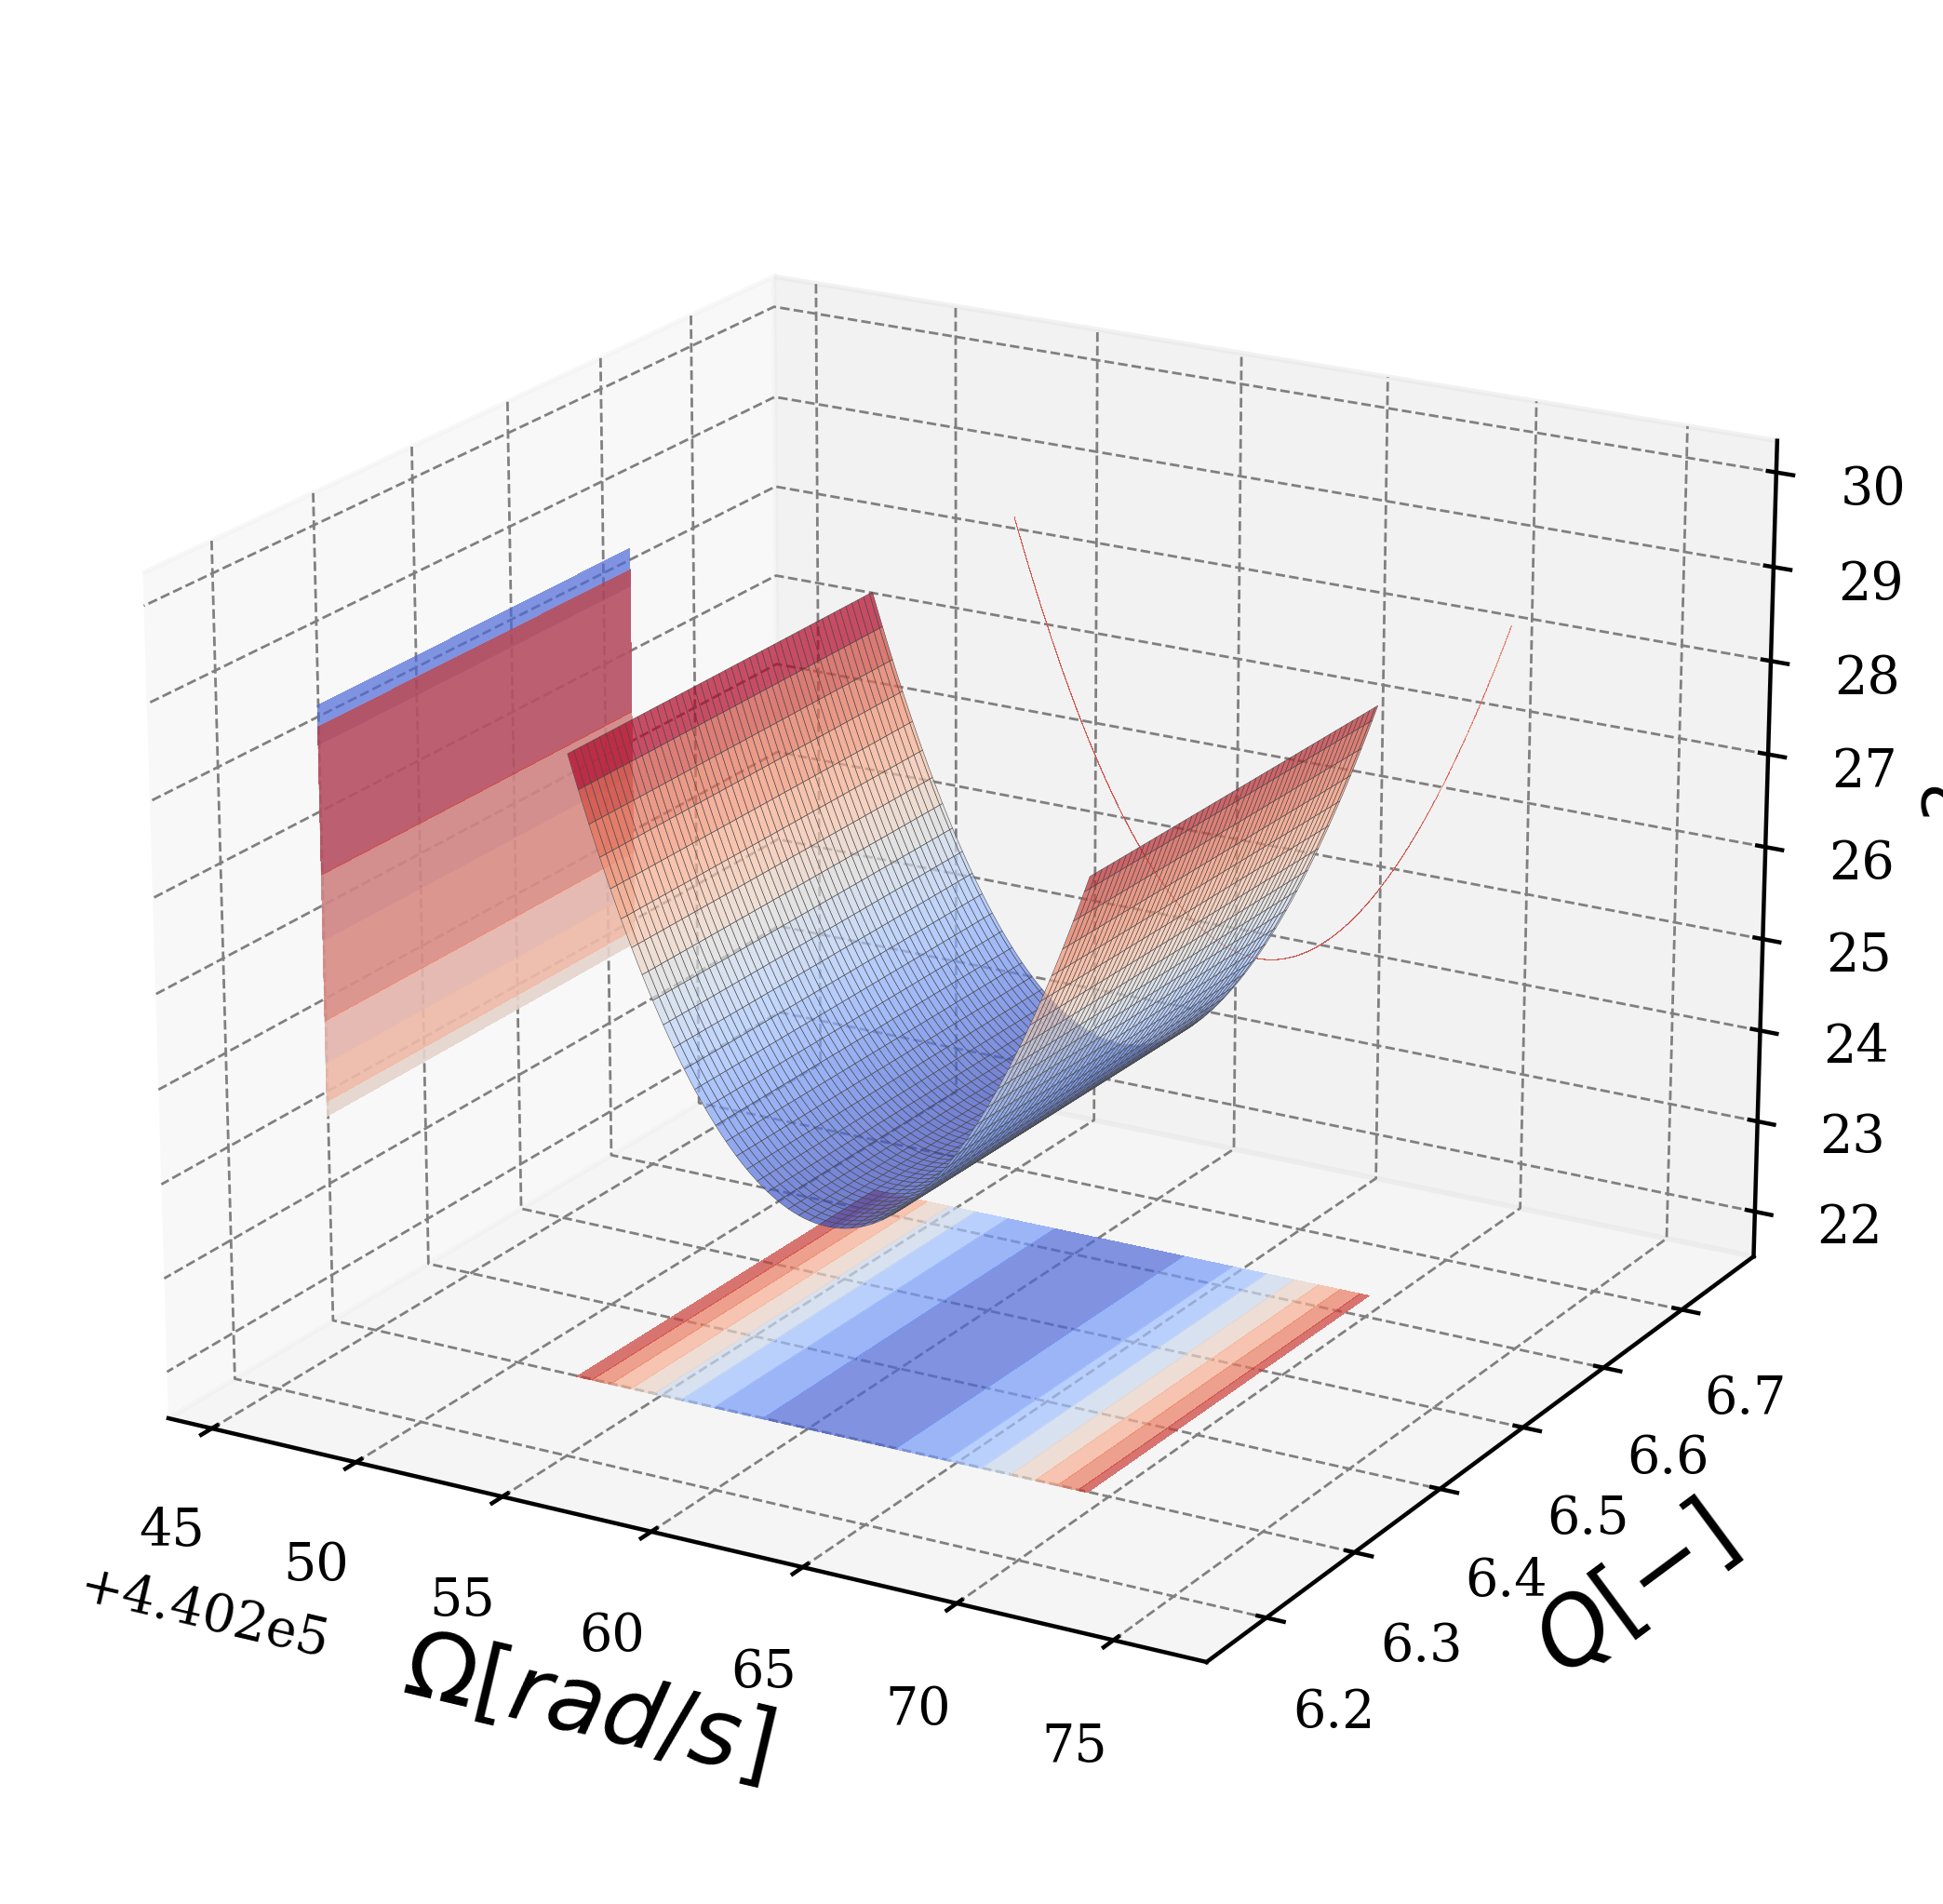

In [208]:
X,Y = np.meshgrid(x_range, y_range)

# Creazione del grafico 3D
fig = plt.figure(constrained_layout=True)
ax = fig.add_subplot(1,1,1, projection='3d')
ax.view_init(elev=20, azim=-60)
ax.set(xlim=xlim, ylim=ylim, zlim=zlim)

# Elementi del grafico
ax.plot_surface(X, Y, xy_map, cmap='coolwarm', edgecolor='0.3', linewidth=0.1, alpha=0.7)
ax.contourf(X, Y, xy_map, zdir='x', offset=xlim[0], cmap='coolwarm', alpha=0.7)
ax.contourf(X, Y, xy_map, zdir='y', offset=ylim[1], cmap='coolwarm', alpha=0.7)
ax.contourf(X, Y, xy_map, zdir='z', offset=zlim[0], cmap='coolwarm', alpha=0.7)
ax.plot(x_range, x_prof, zs=xlim[0], zdir='x', color='black', linewidth=1, linestyle="--")
ax.plot(y_range, y_prof, zs=ylim[1], zdir='y', color='black', linewidth=1, linestyle="--")

# Salvataggio del grafico
ax.set_xlabel("$" + xlabel + "[" + xunit + "]$")
ax.set_ylabel("$" + ylabel + "[" + yunit + "]$")
ax.set_zlabel("$\chi^2$")
let.salva_grafico(fig, grafico_output1)

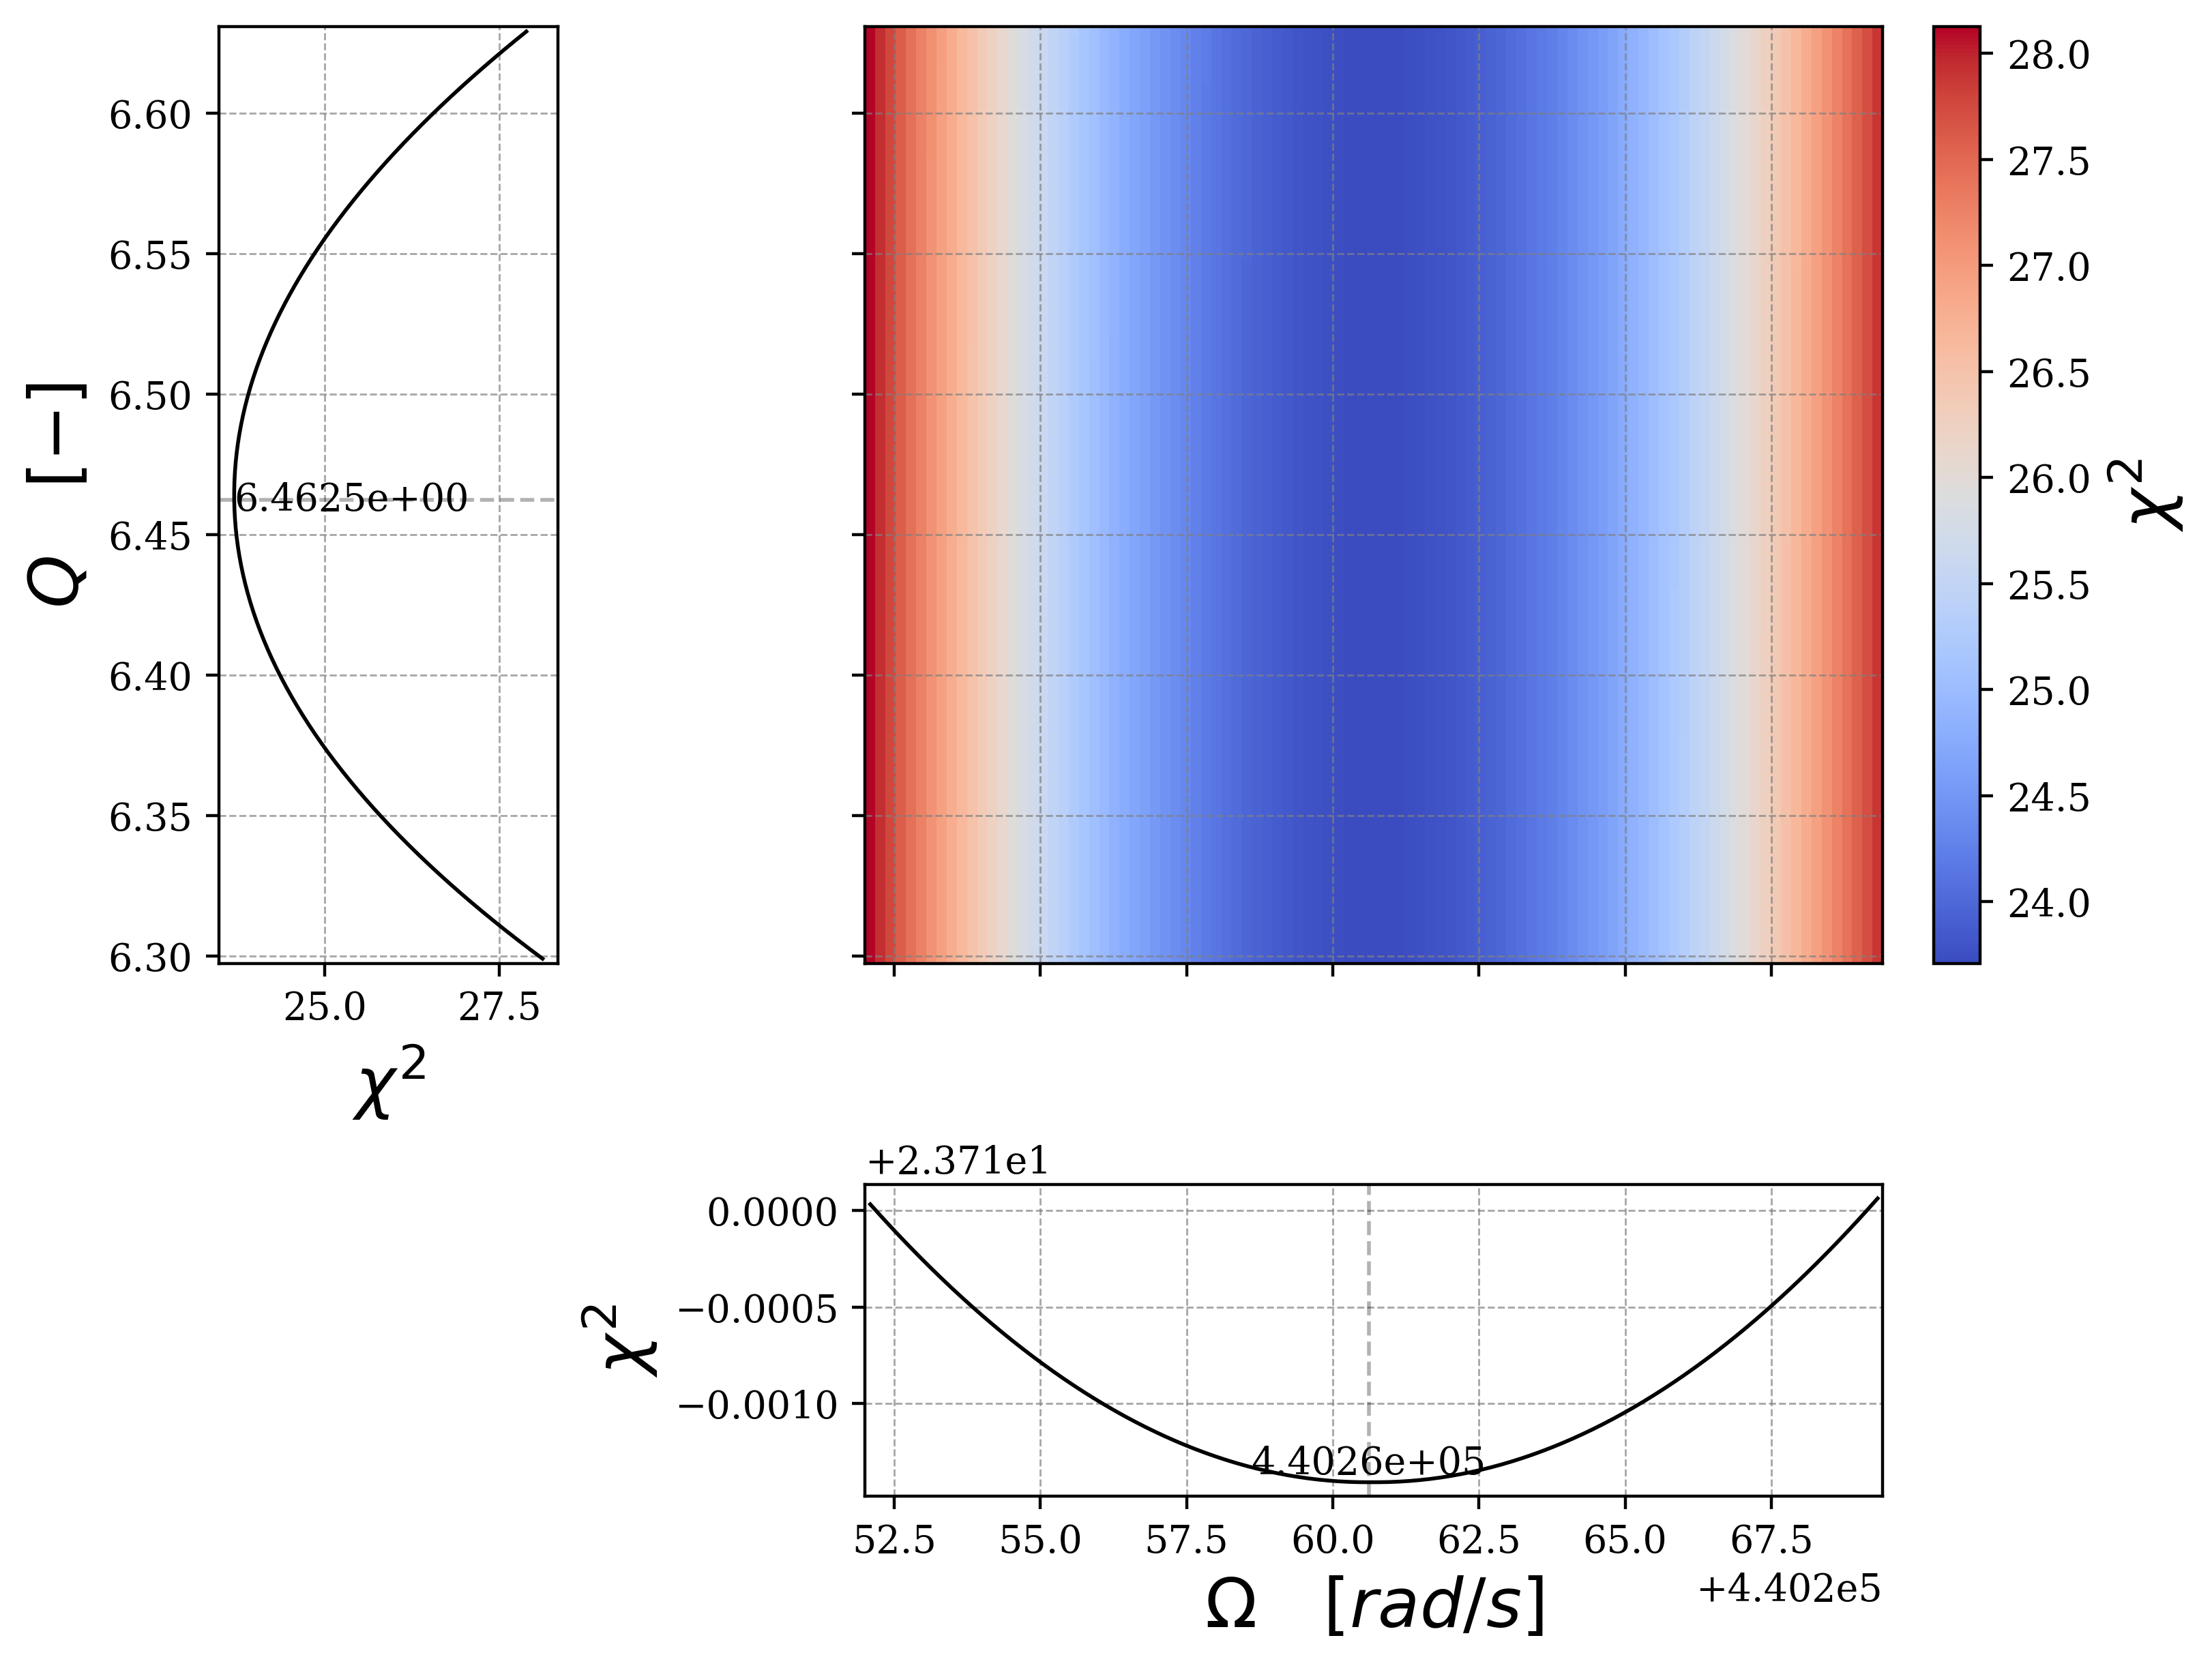

In [209]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 6), constrained_layout=True)

gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[3, 1],
    width_ratios=[1, 3],
    figure=fig
)

ax_main = fig.add_subplot(gs[0, 1])  # 2D chi2 map
ax_b = fig.add_subplot(gs[0, 0], sharey=ax_main)   # sinistra (1D)
ax_blank = fig.add_subplot(gs[1, 0]) # vuoto
ax_a = fig.add_subplot(gs[1, 1], sharex=ax_main)     # sotto (1D)

ax_blank.axis('off')

# =========================
# 2D χ² MAP
# =========================
c = ax_main.pcolormesh(X, Y, xy_map, shading='auto', cmap='coolwarm')
fig.colorbar(c, ax=ax_main, label=r"$\chi^2$")

ax_main.tick_params(axis='x', labelbottom=False)
ax_main.tick_params(axis='y', labelleft=False)

# =========================
# 1D projection B
# =========================
ax_b.plot(y_prof, y_range, color='black', lw=1)
ax_b.axhline(y_min, color='black', linestyle='--', linewidth=1, alpha=0.3) # Linea
ax_b.text(chi_min, y_min, f"{y_min:.4e}", fontsize=10, ha='left', va='center') # Testo
ax_b.set_xlabel(r"$\chi^2$")
ax_b.set_ylabel("$" + ylabel + "\quad[" + yunit + "]$")

# =========================
# 1D projection A
# =========================
ax_a.plot(x_range, x_prof, color='black', lw=1)
ax_a.axvline(x_min, color='black', linestyle='--', linewidth=1, alpha=0.3) # Linea
ax_a.text(x_min, chi_min, f"{x_min:.4e}", fontsize=10, ha='center', va='bottom') # Testo
ax_a.set_xlabel("$" + xlabel + "\quad[" + xunit + "]$")
ax_a.set_ylabel(r"$\chi^2$")

let.salva_grafico(fig, grafico_output2)